# Local UITI_VANO Interpretability

Notebook-first workflow for steps 1-3: circuit/date selection, deterministic critical-point detection, structured context, and optional LLM interpretation.

## 1. Setup and parameters

In [1]:
import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
if load_dotenv:
    load_dotenv(ROOT / ".env")

from chec_local_interpreter.attribution import enrich_critical_points
from chec_local_interpreter.config import CriticalityThresholds, DEFAULT_DATA_PATH, MAX_CRITICAL_POINTS
from chec_local_interpreter.context_builder import build_context_package, critical_points_frame, save_json_artifact
from chec_local_interpreter.critical_points import build_daily_series, compute_daily_features, detect_critical_periods, detect_point_reasons, rank_critical_points
from chec_local_interpreter.data_loader import available_circuits, dataset_summary, filter_events, load_dataset, resolve_columns
from chec_local_interpreter.llm_client import call_llm
from chec_local_interpreter.llm_contracts import PROMPT_VERSION, load_output_schema, render_prompt, save_prompt_artifact
from chec_local_interpreter.llm_skills import assemble_skill_bundle, list_available_skills, verify_required_skills
from chec_local_interpreter.llm_validation import save_invalid_output, validate_llm_response
from chec_local_interpreter.plotting import save_uiti_vano_plot

DATA_PATH = "data/Indicadores_vano_v3.csv"
SELECTED_CIRCUITOS = []
START_DATE = None
END_DATE = None
MAX_CRITICAL_POINTS = MAX_CRITICAL_POINTS
OUTPUT_DIR = ROOT / "outputs"
CALL_LLM = False
LLM_MODEL = os.getenv("LLM_MODEL", "gpt-4.1-mini")
LLM_PROVIDER = "openai"

timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = str((ROOT / DATA_PATH).resolve() if not Path(DATA_PATH).is_absolute() else Path(DATA_PATH))
DATA_PATH

'/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/data/Indicadores_vano_v3.csv'

## 2. Load data

In [2]:
raw_df = load_dataset(DATA_PATH)
column_resolution = resolve_columns(raw_df)
summary = dataset_summary(raw_df)
available = available_circuits(raw_df)
print(f"Dataset shape: {summary['shape']}")
print(f"Date range: {summary['date_min']} to {summary['date_max']}")
print(f"Available circuits: {summary['available_circuits_count']}")
print(f"Selected circuits parameter: {SELECTED_CIRCUITOS or 'all circuits'}")
print(f"Unavailable optional columns: {len(column_resolution.unavailable_optional)}")

Dataset shape: [159470, 273]
Date range: 2025-11-01 to 2026-04-30
Available circuits: 208
Selected circuits parameter: all circuits
Unavailable optional columns: 0


In [3]:
raw_df.head()

,CIRCUITO,FID_SW,COD_EQ_PROTEGE,FID_VANO,T_USUS_EQ_PROT,LVSW,CNT_VN,CNT_VN_SW,FECHA,DURACION,...,clouds_15,clouds_16,clouds_17,clouds_18,clouds_19,clouds_20,clouds_21,clouds_22,clouds_23,clouds_24
0,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-03 23:56:04,0.008,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-18 17:08:14,0.008,...,100.0,100.0,84.0,99.0,99.0,98.0,98.0,97.0,98.0,100.0
2,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-11-19 20:25:50,0.008,...,79.0,99.0,100.0,100.0,100.0,97.0,100.0,100.0,99.0,98.0
3,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-12-10 21:33:41,0.008,...,69.0,93.0,100.0,55.0,61.0,32.0,56.0,59.0,58.0,76.0
4,AGU23L14,20142930,AGU23L14,20139439,1821,2.568,16,22,2025-12-19 15:59:10,0.041,...,99.0,97.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


## 2.1 Circuit Histograms: number of events and UITI

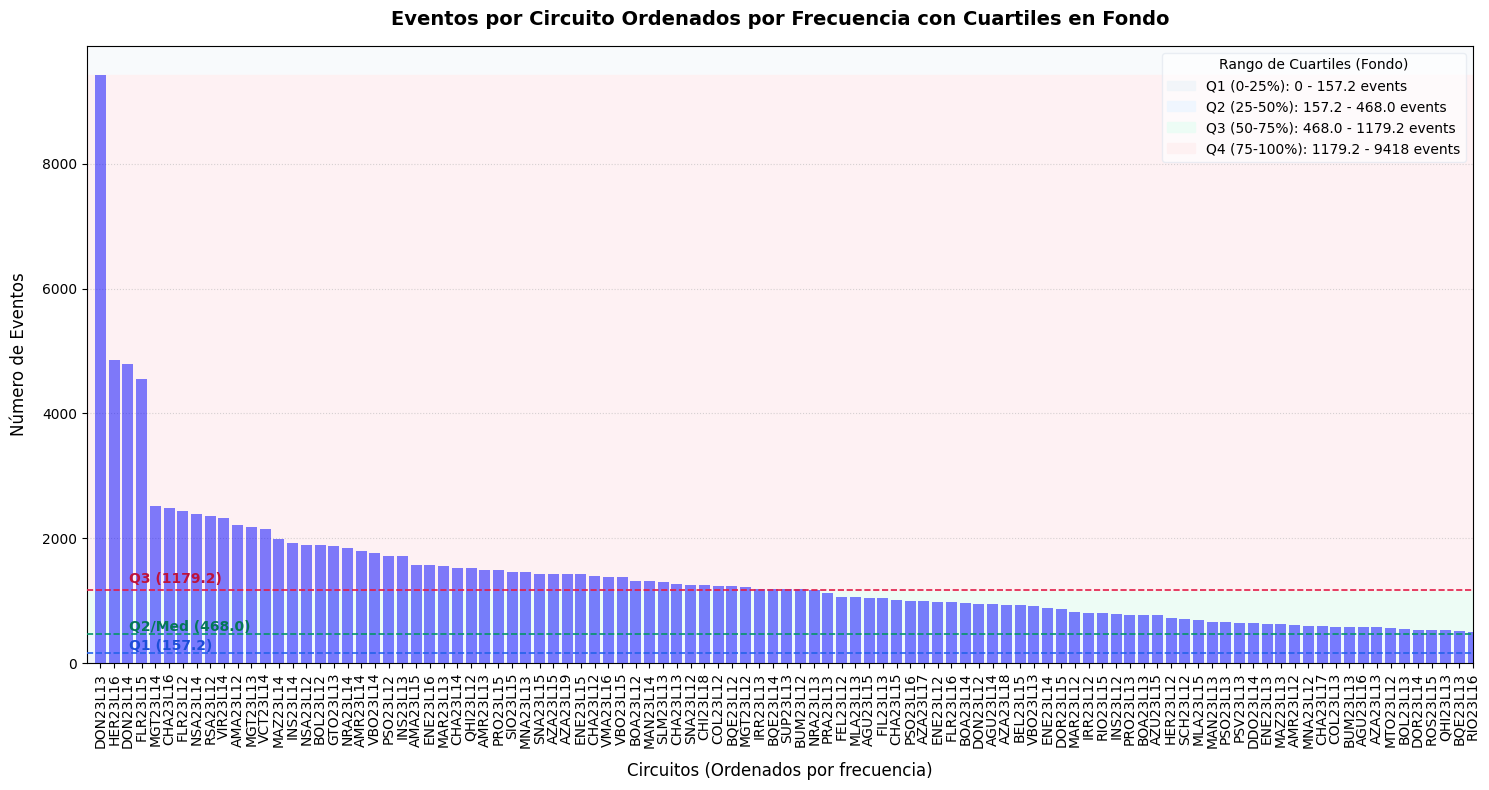

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate the number of events per circuit and sort descending
circuit_counts = raw_df['CIRCUITO'].value_counts().sort_values(ascending=False)

# 2. Compute the quartile boundaries
q1 = circuit_counts.quantile(0.25)
q2 = circuit_counts.quantile(0.50)  # Median
q3 = circuit_counts.quantile(0.75)
min_val = circuit_counts.min()
max_val = circuit_counts.max()

# 3. Create the plot
fig, ax = plt.subplots(figsize=(15, 8))

# High-aesthetic canvas styles (slate-themed)
ax.set_facecolor('#f8fafc')
fig.patch.set_facecolor('#ffffff')

# Plot the bars for all circuits
x_indices = np.arange(len(circuit_counts))
ax.bar(x_indices, circuit_counts.values, color='b', edgecolor='none', width=0.8, zorder=3, alpha=0.5)

# 4. Clean up x-axis circuit labels (showing every 4th label to prevent overlapping)
ax.set_xticks(x_indices)
ax.set_xticklabels(circuit_counts.index, rotation=90, fontsize=10)
#for i, label in enumerate(ax.xaxis.get_ticklabels()):
    #if i % 4 != 0:
    #label.set_visible(False)

# 5. Add horizontal background quartile spans (zorder=1 draws them behind the bars)
colors = ['#f1f5f9', '#eff6ff', '#ecfdf5', '#fff1f2']  # Slate, Blue, Emerald, Rose
ax.axhspan(0, q1, color=colors[0], alpha=0.9, label=f'Q1 (0-25%): 0 - {q1:.1f} events', zorder=1)
ax.axhspan(q1, q2, color=colors[1], alpha=0.9, label=f'Q2 (25-50%): {q1:.1f} - {q2:.1f} events', zorder=1)
ax.axhspan(q2, q3, color=colors[2], alpha=0.9, label=f'Q3 (50-75%): {q2:.1f} - {q3:.1f} events', zorder=1)
ax.axhspan(q3, max_val, color=colors[3], alpha=0.9, label=f'Q4 (75-100%): {q3:.1f} - {max_val} events', zorder=1)

# 6. Draw dashed boundary lines for quartile cuts
ax.axvline = ax.axhline(q1, color='#2563eb', linestyle='--', linewidth=1.2, zorder=4)
ax.axvline = ax.axhline(q2, color='#059669', linestyle='--', linewidth=1.2, zorder=4)
ax.axvline = ax.axhline(q3, color='#e11d48', linestyle='--', linewidth=1.2, zorder=4)

# 7. Add text labels next to the boundaries
x_max = len(circuit_counts)
ax.text(x_max * 0.01, q1 + 50, f'Q1 ({q1:.1f})', color='#1d4ed8', fontsize=10, fontweight='bold', zorder=5)
ax.text(x_max * 0.01, q2 + 50, f'Q2/Med ({q2:.1f})', color='#047857', fontsize=10, fontweight='bold', zorder=5)
ax.text(x_max * 0.01, q3 + 100, f'Q3 ({q3:.1f})', color='#be123c', fontsize=10, fontweight='bold', zorder=5)

# Formatting
max_circuits = 100
ax.set_title('Eventos por Circuito Ordenados por Frecuencia con Cuartiles en Fondo', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Circuitos (Ordenados por frecuencia)', fontsize=12, labelpad=10)
ax.set_ylabel('Número de Eventos', fontsize=12, labelpad=10)
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=2)
if len(circuit_counts)< max_circuits:
    ax.set_xlim(-1, len(circuit_counts))
else:
    ax.set_xlim(-1, max_circuits)
ax.set_ylim(0, max_val * 1.05)

# Legend placement
ax.legend(title='Rango de Cuartiles (Fondo)', loc='upper right', framealpha=0.7, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()


In [4]:
# 1. Ensure UITI_VANO is numeric and handle missing values
raw_df['UITI_VANO'] = pd.to_numeric(raw_df['UITI_VANO'], errors='coerce').fillna(0.0)

# 2. Group by circuit and calculate total UITI_VANO (sorted descending)
circuit_sums = raw_df.groupby('CIRCUITO')['UITI_VANO'].sum().sort_values(ascending=False)

# 3. Compute quartile boundaries for the sums
q1 = circuit_sums.quantile(0.25)
q2 = circuit_sums.quantile(0.50)  # Median
q3 = circuit_sums.quantile(0.75)
min_val = circuit_sums.min()
max_val = circuit_sums.max()

# 4. Create the plot
fig, ax = plt.subplots(figsize=(15, 8))

# High-aesthetic canvas styles (slate-themed)
ax.set_facecolor('#f8fafc')
fig.patch.set_facecolor('#ffffff')

# Plot the bars for all circuits
x_indices = np.arange(len(circuit_sums))
ax.bar(x_indices, circuit_sums.values, color='b', edgecolor='none', width=0.8, zorder=3, alpha=0.5)

# 5. Clean up x-axis circuit labels (showing every 4th label to prevent overlapping)
ax.set_xticks(x_indices)
ax.set_xticklabels(circuit_sums.index, rotation=90, fontsize=10)
#for i, label in enumerate(ax.xaxis.get_ticklabels()):
#    if i % 4 != 0:
#        label.set_visible(False)

# 6. Add horizontal background quartile spans (zorder=1 draws them behind the bars)
colors = ['#f1f5f9', '#eff6ff', '#ecfdf5', '#fff1f2']  # Slate, Blue, Emerald, Rose
ax.axhspan(0, q1, color=colors[0], alpha=0.9, label=f'Q1 (0-25%): 0 - {q1:,.0f}', zorder=1)
ax.axhspan(q1, q2, color=colors[1], alpha=0.9, label=f'Q2 (25-50%): {q1:,.0f} - {q2:,.0f}', zorder=1)
ax.axhspan(q2, q3, color=colors[2], alpha=0.9, label=f'Q3 (50-75%): {q2:,.0f} - {q3:,.0f}', zorder=1)
ax.axhspan(q3, max_val, color=colors[3], alpha=0.9, label=f'Q4 (75-100%): {q3:,.0f} - {max_val:,.0f}', zorder=1)

# 7. Draw dashed boundary lines for quartile cuts
ax.axhline(q1, color='#2563eb', linestyle='--', linewidth=1.2, zorder=4)
ax.axhline(q2, color='#059669', linestyle='--', linewidth=1.2, zorder=4)
ax.axhline(q3, color='#e11d48', linestyle='--', linewidth=1.2, zorder=4)

# 8. Add labels next to the boundaries (adjusted height offset to look clean)
x_max = len(circuit_sums)
ax.text(x_max * 0.01, q1 + (max_val * 0.01), f'Q1 ({q1:,.0f})', color='#1d4ed8', fontsize=10, fontweight='bold', zorder=5)
ax.text(x_max * 0.01, q2 + (max_val * 0.01), f'Q2/Med ({q2:,.0f})', color='#047857', fontsize=10, fontweight='bold', zorder=5)
ax.text(x_max * 0.01, q3 + (max_val * 0.015), f'Q3 ({q3:,.0f})', color='#be123c', fontsize=10, fontweight='bold', zorder=5)

# Formatting
ax.set_title('Suma de UITI_VANO por Circuito Ordenado por Frecuencia con Cuartiles en Fondo', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Circuitos (Ordenados por suma de UITI_VANO)', fontsize=12, labelpad=10)
ax.set_ylabel('Suma de UITI_VANO', fontsize=12, labelpad=10)

# Format y-axis values with commas as thousand separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=2)
if len(circuit_counts)< max_circuits:
    ax.set_xlim(-1, len(circuit_counts))
else:
    ax.set_xlim(-1, max_circuits)
ax.set_ylim(0, max_val * 1.05)

# Legend placement
ax.legend(title='Rango de Cuartiles (Fondo)', loc='upper right', framealpha=0.95, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()


NameError: name 'pd' is not defined

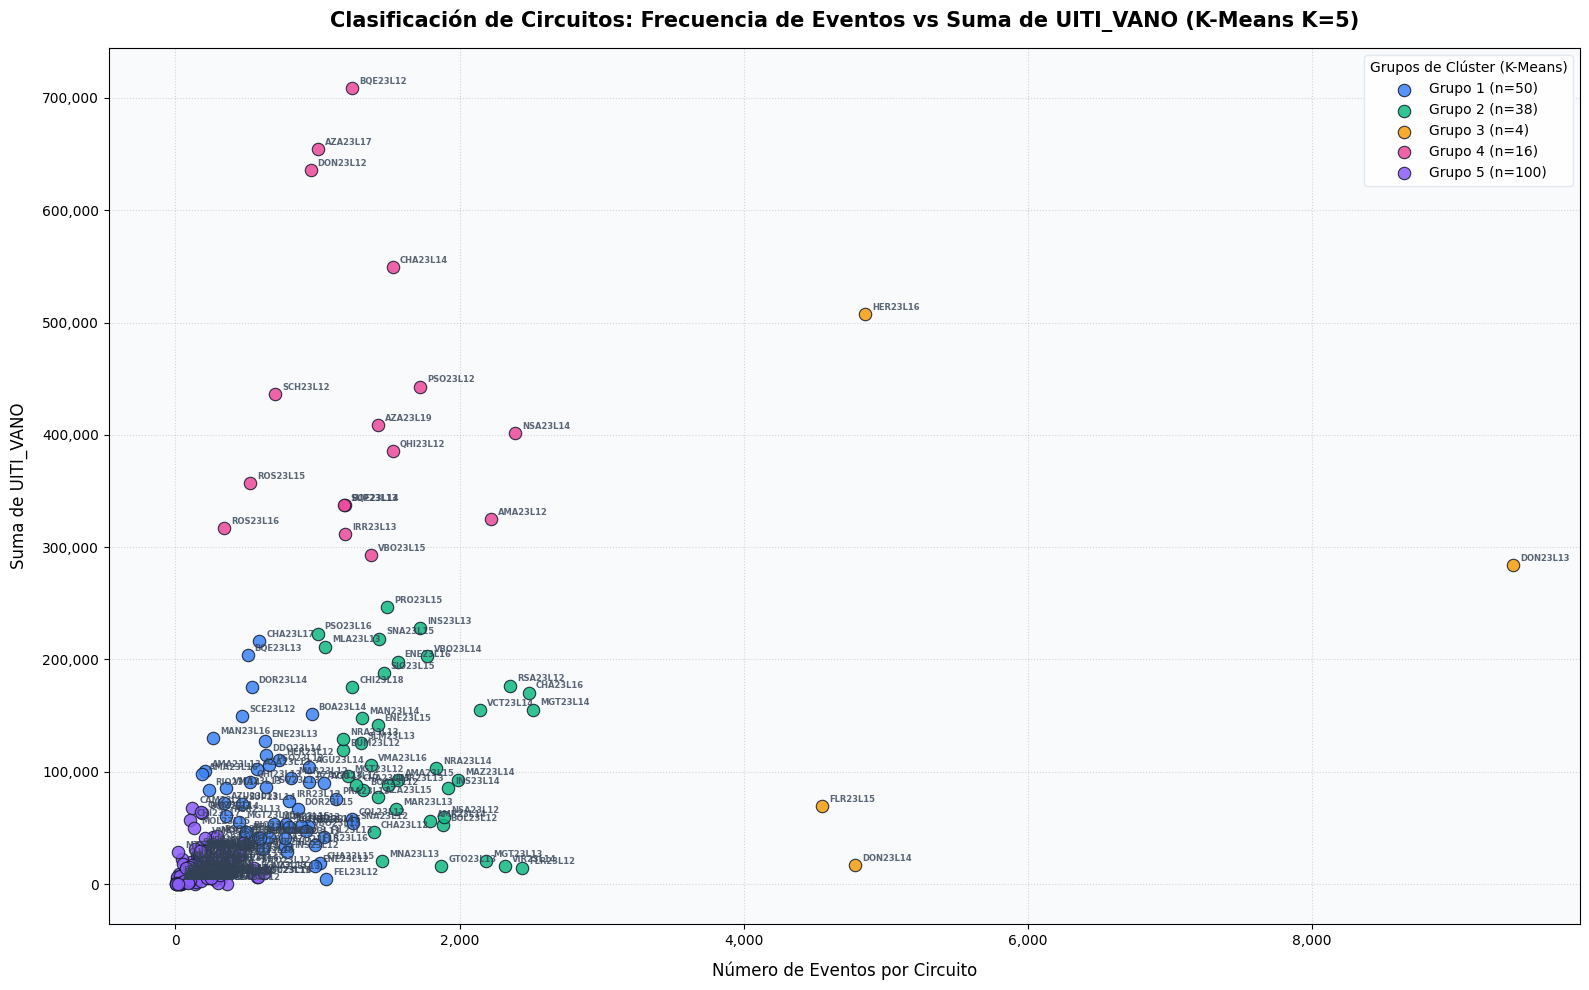

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Preparation
# Ensure UITI_VANO is numeric
raw_df['UITI_VANO'] = pd.to_numeric(raw_df['UITI_VANO'], errors='coerce').fillna(0.0)

# Calculate metrics per circuit
counts = raw_df['CIRCUITO'].value_counts()
sums = raw_df.groupby('CIRCUITO')['UITI_VANO'].sum()

# Merge into a coordinate dataframe
df_coords = pd.DataFrame({
    'event_count': counts,
    'uiti_vano_sum': sums
}).dropna()

# --- FIX: Explicitly cast to float before converting to NumPy values ---
X = df_coords[['event_count', 'uiti_vano_sum']].astype(float).values

# 2. Scaling (Z-score normalization)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

# 3. Custom NumPy K-Means implementation
def run_kmeans(data, n_clusters=5, max_iters=100, random_state=42):
    np.random.seed(random_state)
    centroids = data[np.random.choice(data.shape[0], n_clusters, replace=False)]
    
    for _ in range(max_iters):
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        new_centroids = np.array([
            data[labels == k].mean(axis=0) if np.any(labels == k) else centroids[k]
            for k in range(n_clusters)
        ])
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
        
    return labels

# Execute clustering
df_coords['cluster'] = run_kmeans(X_scaled, n_clusters=5, random_state=42)

# 4. Plotting Setup
fig, ax = plt.subplots(figsize=(16, 10))

# Style customization
ax.set_facecolor('#f8fafc')
fig.patch.set_facecolor('#ffffff')

# Plot clusters
cluster_colors = ['#3b82f6', '#10b981', '#f59e0b', '#ec4899', '#8b5cf6']
for cluster_id in range(5):
    cluster_data = df_coords[df_coords['cluster'] == cluster_id]
    ax.scatter(
        cluster_data['event_count'], 
        cluster_data['uiti_vano_sum'],
        color=cluster_colors[cluster_id],
        s=80, 
        edgecolor='#0f172a', 
        linewidth=0.8,
        label=f'Grupo {cluster_id + 1} (n={len(cluster_data)})',
        alpha=0.85,
        zorder=3
    )

# 5. Labeling every point
for idx, row in df_coords.iterrows():
    ax.annotate(
        idx, 
        (row['event_count'], row['uiti_vano_sum']),
        xytext=(5, 3), 
        textcoords='offset points',
        fontsize=6, 
        color='#334155',
        fontweight='semibold',
        alpha=0.8,
        zorder=4
    )

# Formatting axes
ax.set_title('Clasificación de Circuitos: Frecuencia de Eventos vs Suma de UITI_VANO (K-Means K=5)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Número de Eventos por Circuito', fontsize=12, labelpad=10)
ax.set_ylabel('Suma de UITI_VANO', fontsize=12, labelpad=10)
ax.set_xscale('log')

ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.grid(True, linestyle=':', alpha=0.5, zorder=2)

# Legend
ax.legend(title='Grupos de Clúster (K-Means)', loc='best', framealpha=0.95, facecolor='#ffffff', edgecolor='#e2e8f0')

plt.tight_layout()
plt.show()


## 2.2 ARGIS MAP-based MAPPING

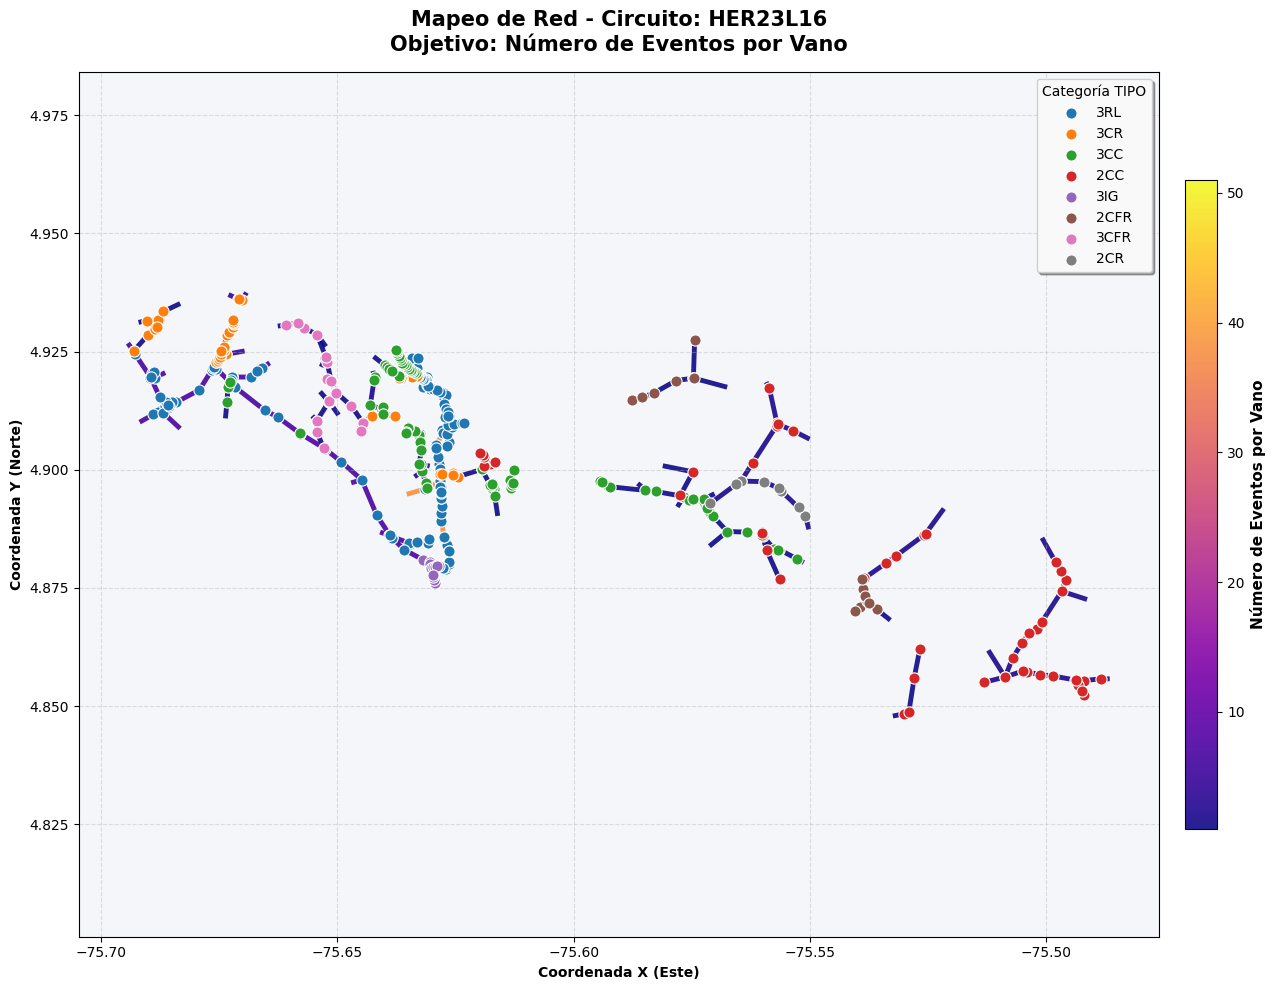

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

def plot_circuit_map(df, circuito_name, date_range=None, color_target='number_of_events'):
    """
    Grafica un mapa del circuito usando coordenadas planas X/Y.
    
    Parámetros:
    - df: DataFrame con los datos crudos
    - circuito_name: Nombre del circuito (ej. 'HER23L16')
    - date_range: Tupla con (fecha_inicio, fecha_fin). Si es None, usa todo el rango histórico.
    - color_target: 'number_of_events' o 'UITI_VANO_sum'.
    """
    # 1. Filtrar por circuito
    df_filtered = df[df['CIRCUITO'] == circuito_name].copy()
    
    # 2. Filtrar por rango de fechas (FECHA) si se proporciona
    if date_range is not None:
        df_filtered['FECHA_parsed'] = pd.to_datetime(df_filtered['FECHA'], errors='coerce')
        start_date, end_date = pd.to_datetime(date_range[0]), pd.to_datetime(date_range[1])
        df_filtered = df_filtered[(df_filtered['FECHA_parsed'] >= start_date) & 
                                  (df_filtered['FECHA_parsed'] <= end_date)]
        
    if df_filtered.empty:
        print(f"No hay datos para el circuito {circuito_name} en el rango de fechas seleccionado.")
        return
        
    # Eliminar filas donde falten las coordenadas espaciales
    coords_cols = ['X1', 'Y1', 'X2', 'Y2']
    df_filtered = df_filtered.dropna(subset=coords_cols)
    
    if df_filtered.empty:
        print("No hay coordenadas válidas (X1, Y1, X2, Y2) para graficar.")
        return

    # Asegurar tipo numérico para las coordenadas y UITI_VANO
    for col in coords_cols:
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')
    df_filtered = df_filtered.dropna(subset=coords_cols)
    df_filtered['UITI_VANO'] = pd.to_numeric(df_filtered['UITI_VANO'], errors='coerce').fillna(0)

    # 3. Calcular la métrica elegida agrupando por Vano (FID_VANO)
    if color_target == 'number_of_events':
        vano_metrics = df_filtered.groupby('FID_VANO').size().to_dict()
        label_colorbar = 'Número de Eventos por Vano'
    elif color_target == 'UITI_VANO_sum':
        vano_metrics = df_filtered.groupby('FID_VANO')['UITI_VANO'].sum().to_dict()
        label_colorbar = 'Suma de UITI_VANO por Vano'
    else:
        print("Error: color_target debe ser 'number_of_events' o 'UITI_VANO_sum'")
        return

    # Asignar la métrica calculada a todas las filas
    df_filtered['metric_value'] = df_filtered['FID_VANO'].map(vano_metrics)

    # Extraer las líneas únicas por Vano para no sobreescribir líneas múltiples veces en la gráfica
    df_lines = df_filtered.drop_duplicates(subset=['FID_VANO']).copy()

    # 4. Configurar la figura de Matplotlib
    fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
    ax.set_facecolor('#f4f6f9') # Fondo suave
    
    # 5. Dibujar las LÍNEAS (Segmentos de Red) coloreadas por la métrica
    lines = []
    line_colors = []
    for _, row in df_lines.iterrows():
        lines.append([(row['X1'], row['Y1']), (row['X2'], row['Y2'])])
        line_colors.append(row['metric_value'])
        
    # Colección de líneas (utilizamos el colormap 'plasma' que resalta muy bien valores altos y bajos)
    lc = LineCollection(lines, cmap='plasma', array=np.array(line_colors), linewidths=3.5, zorder=1, alpha=0.9)
    line_obj = ax.add_collection(lc)
    
    # Añadir el Colorbar para las líneas
    cbar = fig.colorbar(line_obj, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label(label_colorbar, fontweight='bold', fontsize=11)
    
    # 6. Dibujar los PUNTOS (Estructuras X1, Y1) coloreados categóricamente por TIPO
    # Obtenemos puntos únicos para la leyenda
    df_points = df_filtered.drop_duplicates(subset=['X1', 'Y1', 'TIPO']).copy()
    
    unique_tipos = df_points['TIPO'].unique()
    colors_cycle = list(mcolors.TABLEAU_COLORS.values())
    tipo_color_map = {tipo: colors_cycle[i % len(colors_cycle)] for i, tipo in enumerate(unique_tipos)}
    
    for tipo in unique_tipos:
        df_tipo = df_points[df_points['TIPO'] == tipo]
        ax.scatter(df_tipo['X1'], df_tipo['Y1'], 
                   color=tipo_color_map[tipo], 
                   label=str(tipo), 
                   s=65, edgecolors='white', linewidth=0.8, zorder=2)

    # 7. Títulos, Leyendas y Formato del Gráfico
    ax.set_title(f"Mapeo de Red - Circuito: {circuito_name}\nObjetivo: {label_colorbar}", 
                 fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel("Coordenada X (Este)", fontweight='bold')
    ax.set_ylabel("Coordenada Y (Norte)", fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # Leyenda para los TIPOS (puntos)
    ax.legend(title="Categoría TIPO", loc="upper right", framealpha=0.95, shadow=True)
    
    # Esto es MUY IMPORTANTE: Evita que el mapa se distorsione, forzando escala geométrica real 1:1
    ax.set_aspect('equal', 'datalim')
    ax.autoscale_view()

    plt.tight_layout()
    plt.show()

# =================================================================
# Ejemplo de uso tal como lo solicitaste:
# =================================================================
# Asumiendo que tu DataFrame crudo se llama 'raw_df'
plot_circuit_map(
    df=raw_df, 
    circuito_name='HER23L16', 
    date_range=None, # None indica que use todo el rango de fechas disponible
    color_target='number_of_events'
)


In [9]:
#%pip install arcgis

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def plot_circuit_map_plotly(df, circuito_name, date_range=None, color_target='number_of_events'):
    # 1. Filtrar por circuito
    df_filtered = df[df['CIRCUITO'] == circuito_name].copy()
    
    # 2. Filtrar por fechas
    if date_range is not None:
        df_filtered['FECHA_parsed'] = pd.to_datetime(df_filtered['FECHA'], errors='coerce')
        start_date, end_date = pd.to_datetime(date_range[0]), pd.to_datetime(date_range[1])
        df_filtered = df_filtered[(df_filtered['FECHA_parsed'] >= start_date) & 
                                  (df_filtered['FECHA_parsed'] <= end_date)]
        
    coords_cols = ['X1', 'Y1', 'X2', 'Y2']
    df_filtered = df_filtered.dropna(subset=coords_cols)
    if df_filtered.empty:
        print(f"No hay coordenadas válidas para {circuito_name}.")
        return 
        
    for col in coords_cols:
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')
    df_filtered = df_filtered.dropna(subset=coords_cols)
    df_filtered['UITI_VANO'] = pd.to_numeric(df_filtered['UITI_VANO'], errors='coerce').fillna(0)

    # 3. Calcular la métrica
    if color_target == 'number_of_events':
        vano_metrics = df_filtered.groupby('FID_VANO').size().to_dict()
        cbar_title = 'Número de Eventos'
    elif color_target == 'UITI_VANO_sum':
        vano_metrics = df_filtered.groupby('FID_VANO')['UITI_VANO'].sum().to_dict()
        cbar_title = 'Suma de UITI_VANO'
        
    df_filtered['metric_value'] = df_filtered['FID_VANO'].map(vano_metrics)
    df_lines = df_filtered.drop_duplicates(subset=['FID_VANO']).copy()
    
    # ==========================================
    # MEJORA DE VISIBILIDAD: Escala Robusta
    # ==========================================
    vmin = df_lines['metric_value'].min()
    # Usar el percentil 95 o 98 evita que 1 vano atípico arruine todo el contraste de colores
    vmax_robust = np.percentile(df_lines['metric_value'], 95)
    
    # Si todos los valores son iguales, ajustamos
    if vmax_robust <= vmin:
        vmax_robust = df_lines['metric_value'].max()
        if vmax_robust == vmin:
            vmax_robust = vmin + 1

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax_robust)
    mapper = cm.ScalarMappable(norm=norm, cmap=cm.turbo) # 'turbo' tiene el mejor contraste
    
    fig = go.Figure()
    
    # Colorbar
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(
            colorscale='Turbo', cmin=vmin, cmax=vmax_robust,
            colorbar=dict(title=dict(text=f"{cbar_title}<br>(Corte al p95)", font=dict(weight='bold')), thickness=15, len=0.8),
            showscale=True
        ),
        showlegend=False, hoverinfo='none'
    ))

    # ==========================================
    # MEJORA DE VISIBILIDAD: Líneas más gruesas
    # ==========================================
    for _, row in df_lines.iterrows():
        val = row['metric_value']
        color_rgba = mapper.to_rgba(val, bytes=True)
        hex_color = f'#{color_rgba[0]:02x}{color_rgba[1]:02x}{color_rgba[2]:02x}'
        
        fig.add_trace(go.Scatter(
            x=[row['X1'], row['X2']],
            y=[row['Y1'], row['Y2']],
            mode='lines',
            line=dict(color=hex_color, width=4.5), # Línea más gruesa (4.5)
            hoverinfo='text',
            text=f"FID_VANO: {row['FID_VANO']}<br>{cbar_title}: {val}",
            showlegend=False,
            opacity=0.9
        ))
        
    # ==========================================
    # MEJORA DE VISIBILIDAD: Puntos más discretos
    # ==========================================
    df_points = df_filtered.drop_duplicates(subset=['X1', 'Y1', 'TIPO']).copy()
    tipos = df_points['TIPO'].unique()
    colors_px = px.colors.qualitative.Plotly
    
    for i, tipo in enumerate(tipos):
        dft = df_points[df_points['TIPO'] == tipo]
        fig.add_trace(go.Scatter(
            x=dft['X1'], y=dft['Y1'],
            mode='markers',
            marker=dict(size=7, opacity=0.75, color=colors_px[i % len(colors_px)], line=dict(width=0.5, color='white')), 
            name=f"TIPO: {tipo}",
            hoverinfo='text',
            text=dft.apply(lambda r: f"TIPO: {r['TIPO']}", axis=1)
        ))

    fig.update_layout(
        title=dict(text=f"Mapa de Red - Circuito: {circuito_name}<br><sup>Líneas engrosadas y contraste de color optimizado</sup>", font=dict(size=18)),
        xaxis_title="Coordenada X (Este)",
        yaxis_title="Coordenada Y (Norte)",
        #plot_bgcolor='#2b3035', # Fondo oscuro opcional para que los colores brillen más (ajusta si prefieres claro)
        yaxis=dict(scaleanchor="x", scaleratio=1),
        width=1000, height=800,
        legend=dict(title="Equipos (TIPO)", yanchor="top", y=0.99, xanchor="right", x=0.01, bgcolor="rgba(255, 255, 255, 0.8)")
    )
    
    fig.show()

# =================================================================
# Ejemplo de uso:
# =================================================================
plot_circuit_map_plotly(
    df=raw_df, 
    circuito_name='HER23L16', 
    date_range=None, 
    color_target='number_of_events'
)




In [14]:
plot_circuit_map_plotly(
    df=raw_df, 
    circuito_name='HER23L16', 
    date_range=None, 
    color_target='UITI_VANO_sum'
)

## 3. Filter dataset

In [ ]:
events_df = filter_events(
    raw_df,
    selected_circuitos=SELECTED_CIRCUITOS,
    start_date=START_DATE,
    end_date=END_DATE,
)
selected_circuitos_effective = SELECTED_CIRCUITOS or sorted(events_df['CIRCUITO'].dropna().astype(str).unique().tolist())
start_effective = START_DATE or (events_df['fecha_dia'].min().date().isoformat() if not events_df.empty else None)
end_effective = END_DATE or (events_df['fecha_dia'].max().date().isoformat() if not events_df.empty else None)
print(f"Filtered rows: {len(events_df)}")
print(f"Effective circuits: {selected_circuitos_effective[:10]}{' ...' if len(selected_circuitos_effective) > 10 else ''}")
print(f"Effective window: {start_effective} to {end_effective}")

## 4. Build daily UITI_VANO series

In [ ]:
daily_df = build_daily_series(events_df)
display(daily_df.head())
print(f"Daily rows: {len(daily_df)}")
print(f"Total UITI_VANO: {daily_df['UITI_VANO'].sum() if not daily_df.empty else 0}")

## 5. Detect relevant/critical points

In [ ]:
thresholds = CriticalityThresholds(max_points=MAX_CRITICAL_POINTS)
feature_df = compute_daily_features(daily_df, metric="UITI_VANO")
reasons = detect_point_reasons(feature_df, thresholds=thresholds, metric="UITI_VANO")
critical_points = rank_critical_points(feature_df, reasons, max_points=MAX_CRITICAL_POINTS, metric="UITI_VANO")
critical_periods = detect_critical_periods(feature_df, thresholds=thresholds, metric="UITI_VANO")
display(critical_points_frame(critical_points))
critical_periods

## 6. Enrich critical points

In [ ]:
critical_points = enrich_critical_points(events_df, critical_points)
print(f"Enriched critical points: {len(critical_points)}")
critical_points[:1]

## 7. Build structured context JSON

In [ ]:
context_package = build_context_package(
    events_df=events_df,
    daily_df=daily_df,
    critical_points=critical_points,
    critical_periods=critical_periods,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
)
print(json.dumps({
    'analysis_name': context_package['analysis_name'],
    'selected_context': context_package['selected_context'],
    'window_summary': context_package['window_summary'],
    'critical_point_count': len(context_package['critical_points']),
}, ensure_ascii=False, indent=2))

## 8. Save artifacts

In [ ]:
context_path = save_json_artifact(context_package, OUTPUT_DIR / f"structured_context_{timestamp}.json")
critical_csv_path = OUTPUT_DIR / f"critical_points_{timestamp}.csv"
critical_points_frame(critical_points).to_csv(critical_csv_path, index=False)
plot_path = save_uiti_vano_plot(
    daily_df,
    critical_points,
    selected_circuitos=selected_circuitos_effective,
    start_date=start_effective,
    end_date=end_effective,
    output_path=OUTPUT_DIR / f"uiti_vano_timeseries_{timestamp}.png",
)
print(context_path)
print(critical_csv_path)
print(plot_path)

## 9. LLM skills, contracts, and validation

In [ ]:
missing_skills = verify_required_skills()
if missing_skills:
    raise FileNotFoundError(f"Missing required LLM skills: {missing_skills}")
skills = list_available_skills()
skill_bundle = assemble_skill_bundle()
output_schema = load_output_schema()
prompt = render_prompt(
    context_json=json.dumps(context_package, ensure_ascii=False, indent=2),
    output_schema_json=json.dumps(output_schema, ensure_ascii=False, indent=2),
    prompt_version=PROMPT_VERSION,
)
prompt_path = save_prompt_artifact(prompt, OUTPUT_DIR / f"llm_prompt_{timestamp}.md")
print(f"Loaded skills: {skills}")
print(f"Prompt saved: {prompt_path}")
print(f"Skill bundle characters: {len(skill_bundle)}")

In [ ]:
llm_result = call_llm(
    prompt,
    provider=LLM_PROVIDER,
    model=LLM_MODEL,
    call_enabled=CALL_LLM,
)
print(llm_result.message)

if llm_result.output_text:
    validation = validate_llm_response(llm_result.output_text, context_package, output_schema)
    if validation.ok:
        analysis_path = save_json_artifact(validation.data, OUTPUT_DIR / f"llm_analysis_{timestamp}.json")
        print(f"Valid LLM analysis saved: {analysis_path}")
        display(validation.data)
    else:
        raw_path, errors_path = save_invalid_output(llm_result.output_text, validation.errors, OUTPUT_DIR, timestamp)
        print("LLM output did not validate. Prompt and context were saved for manual review.")
        print(raw_path)
        print(errors_path)
        print(validation.errors)